# This is a follow-up to the `discrete_time_adjoint.ipynb` notebook. 
- Here, I discuss sensitivity to parameters on the RHS of a discrete-time dynamical system. 
- Eventually, we will want to use the $L^2$ error objective discussed in the previous notebook. 
- Finally, we will implement a neural RHS.

In [1]:
using LinearAlgebra
using SparseArrays
using Statistics
using Plots
using OrdinaryDiffEq
using OrdinaryDiffEqSDIRK
using Random
using BenchmarkTools
using Printf

include("useful_functions.jl")

solve_simple_adjoint_AC_1d (generic function with 1 method)

## Background


### A Simple Objective

Let's take the simple recurrence relation $x_{n+1}=f_p(x_n)$ for $n \in \{0,...,N\}$ given $x_0$ with the objective $J = y^Tx_N.$ Here, $f_p$ is a function parametrized by a parameter $p$.

Well, as in the previous notebook, $$\frac{dJ}{dx_0} = \frac{\delta J}{\delta x_N}\frac{\delta x_N}{\delta x_{N-1}} \cdots \frac{\delta x_1}{\delta x_0}.$$ So we can still build an adjoint equation as before, via $$v_{n} = (\frac{\delta x_{n+1}}{\delta x_{n}})^Tv_{n+1} $$ with $v_N = y$, and we get $$v_n = (\frac{dJ}{dx_n})^T.$$

What if I care about $\frac{dJ}{dp}$? Well, for an intermediate step, $$\frac{d x_n}{d p}= \frac{d f_p(x_{n-1})}{d p} = \frac{\delta f_p(x_{n-1})}{\delta x_{n-1}}\frac{d x_{n-1}}{d p} + \frac{\delta f_p(x_{n-1})}{\delta p}\frac{d p}{d p}= \\ \\=  \frac{\delta x_n}{\delta x_{n-1}}\frac{d x_{n-1}}{d p} + \frac{\delta f_p(x_{n-1})}{\delta p}.$$ 

In the last step, I've replaced $f_p(x_{n-1})$ with $x_n$ suggestively; this should look like the adjoint recurrence relation above. Can we build a similar recurrence relation that propagates this parameter dependence backward? Yes, we can, but the proof is a bit long, so you'll have to trust me that we get the formula $$\frac{dJ}{dp} = \sum_{n=0}^{N-1}v_{n+1}^T \frac{\delta f_p(x_n)}{\delta p}.$$




### Testing These Formulas

Let's test this relation with an intuitive example. Take the simple one-dimensional ODE $x_t = px(t)$, which is solved by $x(t) = x_0e^{pt}$. We can model this with $x_{n+1} = x_n + \Delta t x_t = x_n + \Delta t px_n = (1+p\Delta t)x_n$. Then our terminal state is $x_N = (1+p\Delta t)^Nx_0$. If our objective function is $J = \mathbf{1} \cdot x_N = 1x_N = x_N$, then we have $J = (1+p\Delta t)^Nx_0.$ Thus, $$\frac{dJ}{dp} = N\Delta t(1+p\Delta t)^{N-1}x_0 = T x_{N-1},$$ where $T=N\Delta t.$

What about our adjoint method? Well, we have $v_N = y = 1$, and the recurrence relation $v_{n} = (\frac{\delta x_{n+1}}{\delta x_{n}})^Tv_{n+1}= (1+p\Delta t) v_{n+1} = (1+p\Delta t)^{N-n}v_N = (1+p\Delta t)^{N-n}$. Further, we have $\frac{\delta f_p(x_n)}{\delta p} = x_n \Delta t$. Hence, according to the formula above, we should have $$\frac{dJ}{dp} = \sum_{n=0}^{N-1}v_{n+1}^T \frac{\delta f_p(x_n)}{\delta p} = \sum_{n=0}^{N-1}(1+p\Delta t)^{N-n-1}x_n \Delta t.$$ But at each $n$, $$(1+p\Delta t)^{N-n-1}x_n = x_{N-1},$$ so we get $$ \Delta t x_{N-1} \sum_{n=0}^{N-1} 1 = N \Delta t x_{N-1} = Tx_{N-1}.$$

### The Neural RHS

Examining  $$\frac{dJ}{dp} = \sum_{n=0}^{N-1}v_{n+1}^T \frac{\delta f_p(x_n)}{\delta p},$$ we see a process similar to backpropagation, a forward pass (the right term) and a backward pass (the adjoints). If our $f_p$ is itself a neural network, and $p$ is a parameter (say, a weight or a bias), we can calculate $\frac{\delta f_p(x_n)}{\delta p}$ by backpropagating through the neural network. In this case, to calculate $\frac{\delta f_p(x_n)}{\delta p}$, we solve the equivalent of an adjoint equation for our network, but now our "state" vector, $x_n$, is the output of a step of our NN computational graph (eg. activation function, weight matrix multiplication, bias addition), and the recurrence relation is the map from one step of our NN to the next. 

We can think of our objective function as $J^{NN}= v_{n+1}^T f_p(x_n)$ for a fixed (ie independent of $p$) $v_{n+1}$. Here, $v_{n+1}^T$ takes the place of $y$ from our end-state nonlinear objective calculation in the previous notebook. Note that, as $v$ is independent of $p$ here, $\frac{dJ^{NN}}{dp} =  v_{n+1}^T \frac{\delta f_p(x_n)}{\delta p}$. Thus, making use of our previous work on nonlinear adjoints, we propagate our test functional $v_{n+1}$ via the adjoint recurrence relation $\nu_{l} = (\frac{\delta s_{l+1}}{\delta s_l} )^T \nu_{l+1}$, $\nu_L = v_{n+1}$. Here, $L$ is the number of "steps," in our network's computational graph and $s$ is the "state" vector describing each output of each step. As before, we have the very simple $$\nu_l = (\frac{dJ^{NN}}{ds_l})^T.$$

The important point is that now $p$ (a scalar parameter in our network) is to our neural network as a point on the trajectory curve ($x_{n,i}$) was to our differential equation. 

As an aside, as we have seen in the previous notebook, when computing an adjoint with respect to state for a composition of linear maps, we do not actually require the intermediate states. We require the intermediate activations for backpropagation because our network is (intentionally) nonlinear. 

### The $L^2$ objective function. 

We are very close to implementing a Neural PDE, but our current objective function is not very useful. How do we use the $L^2$ objective in the previous notebook? We now have a nonlinear recurrence relation, and we want the $\frac{dJ}{dp}$, not $\frac{dJ}{dx_0}$. 

As often with (adjoint) differential equations, we will pull a recurrence relation out of thin air: take $$ v_n = (\frac{\delta f_p(x_n)} {\delta x_n} )^T v_{n+1} + (x_n - u_n),$$ where $u_n$ is the "true" trajectory to which $x$ is being compared, with $v_N = x_N - u_N.$ Then we arrive at $$\frac{dJ}{dp} = \sum_{n=0}^{N-1}v_{n+1}^T \frac{\delta f_p(x_n)}{\delta p}$$ once again! The proof is somewhat long and tedious, but unsurprisingly follows the same steps as the proofs above and in the previous notebook. Note that here, we're writing our trajectory $L^2$ error as $$J = \frac{1}{2} \sum_{n=0}^N || x_n - u_n||^2.$$

## Implementation

### Our Goal

As a first pass, we will try to build a neural ODE. Of course, as we can see in the key equation above (one might call it the backpropagation equation), the process of learning only one part of the RHS operator is nearly identical to learning the whole operator; one only need adjust the the computation of $\frac{\delta f_p(x_n)}{\delta p}.$ The purpose, of course, of calculating the sensitivity of our objective $J$ to parameters is that we would like to perform stochasic gradient descent in parameter-space. 

We're going to try to learn the whole RHS of the Allen Cahn equation. I have no idea if this will work. 

We can write Allen-Cahn as $$x_{n+1} = f(x_n) = [I+\Delta t(\Delta -f_c)](x_n).$$ We would like to train a neural network $N_\theta$ to approximate $f$. Our neural network will be composed of weights and biases with a nonlinear sigmoid activation, of the form $$N(x) = \sigma_L(W_L(\cdot\cdot\cdot(\sigma_1(W_1x+b_1)))+b_L).$$ As discussed above, we can model $N$ as a differentiable recurrence relation with objective function $v_{n+1}^TN(x_n)$. 

### Working Code

#### True Allen-Cahn trajectory

We first generate one true trajectory from the sine initial condition. This is the only data used below.


In [71]:
# small explicit-Euler problem so the hand-written training loop stays readable

Random.seed!(1)

Nx_train = 40
κ_train = 0.1
T_train = .5
L_train = 1.0
Nsteps_train = 500

x_train = LinRange(0, L_train, Nx_train)
u₀_train = sin.(π .* x_train)

true_AC = solve_forward_AC_1d(u₀_train, T_train, L_train, Nx_train, κ_train, Nsteps_train; periodic=false)

training_errors = Dict{Symbol, Vector{Float64}}()
stored_trajectories = Dict{Symbol, NamedTuple}()


homogenous dirichlet boundary conditions


Dict{Symbol, NamedTuple}()

#### Neural time-stepper

The neural PDE is just a trainable time-step map. One call to the network advances one time step.


In [72]:
sigmoid(z) = 1 ./ (1 .+ exp.(-z))
sigmoid_prime_from_output(s) = @. s * (1 - s)

# randomly initialize a two-layer neural network
# do we want to compress information? unclear atm 
function init_params(Nx, hidden)
    return (
        W1 = 0.2 .* randn(hidden, Nx),
        b1 = zeros(hidden),
        W2 = 0.2 .* randn(Nx, hidden),
        b2 = zeros(Nx),
    )
end

# standard NN with sigmoid activation functions 
function nn_step(θ, x)
    z1 = θ.W1 * x .+ θ.b1
    s1 = sigmoid(z1)
    z2 = θ.W2 * s1 .+ θ.b2
    # i adjusted to a linear final activation instead of sigmoid#
    # hopefully this works better
    s2 = z2
    return s2, (x=x, z1=z1, s1=s1, z2=z2, s2=s2)
end

# rollout steps the neural PDE for a trajectory of length `horizon`
# in addition to storing the whole x trajectory, it stores the intermediate states
# of the network
function rollout(θ, x₀, horizon)
    x = zeros(length(x₀), horizon + 1)
    caches = Vector{Any}(undef, horizon)
    x[:,1] .= x₀

    for n in 1:horizon
        x[:,n+1], caches[n] = nn_step(θ, x[:,n])
    end

    return x, caches
end


rollout (generic function with 1 method)

#### Adjoint gradient for one training window

This is the manual backpropagation calculation. The trajectory adjoint supplies the seed for each neural-network backward pass.


In [73]:
# build a tuple to store the gradients of all the parameters
function zero_grads(θ)
    return (
        W1 = zeros(size(θ.W1)),
        b1 = zeros(size(θ.b1)),
        W2 = zeros(size(θ.W2)),
        b2 = zeros(size(θ.b2)),
    )
end

# a function for updating gradients from collection of trajectories (say, within a minibatch)
function add_grads!(g, h)
    g.W1 .+= h.W1; g.b1 .+= h.b1
    g.W2 .+= h.W2; g.b2 .+= h.b2
    return nothing
end

 
function scale_grads!(g, c)
    g.W1 .*= c; g.b1 .*= c
    g.W2 .*= c; g.b2 .*= c
    return nothing
end

# perform gradient descent with some learning rate
function update!(θ, g, η)
    θ.W1 .-= η .* g.W1; θ.b1 .-= η .* g.b1
    θ.W2 .-= η .* g.W2; θ.b2 .-= η .* g.b2
    return nothing
end

# this is backpropagation, coded manually
# our adjoint starts at 'seed,' then is propagated back by the Jacobian wrt each step's input 
# recall that our objective function is J = v^T Nₚ(x) (where v is the ODE adjoint)
# for example, to calculate dJ/db₂, we do the chain rule: dJ/db₂ = dJ/ds₂*ds₂/db₂. 
# That first term, dJ/ds₂, is v, our seed. The second term is stored below as δ₂. 

#Update: I switched to a linear final activation because sigmoid wasn't working. So now the derivative is super easy. 

# Everything else is just chain rule. 
# We could also write this as an adjoint equation, as described above
# however, because our recurrence relation alternates between the sigmoid, weight multiplication, and bias addition,
# that's about as tedious as just writing it out by hand

# why are we returning this last step? Well, check out the adjoint recurrence relation in the L^2 objective
# section above. We need df_p(x)/dx to propagate our adjoint.
function add_nn_grad!(g, θ, cache, seed)
    δ2 = seed
    g.W2 .+= δ2 * cache.s1'
    g.b2 .+= δ2

    δ1 = (θ.W2' * δ2) .* sigmoid_prime_from_output(cache.s1)
    g.W1 .+= δ1 * cache.x'
    g.b1 .+= δ1

    return θ.W1' * δ1
end


# finally, we can compute a neural trajectory and update our gradients accordingly. 
# i'll comment here line by line
# true window is the 'real' trajectory we're trying to match
# our params are θ
function window_loss_grad(θ, true_window)
    horizon = size(true_window, 2) - 1

    # solve a neural trajectory; store all the intermediate activations
    # initial condition is the initial condition of the 'true' trajectory
    pred, caches = rollout(θ, true_window[:,1], horizon)

    # compute a loss; in this case, we're using the average L2 error over time. 
    normalizer = length(pred)
    loss = 0.5 * sum(abs2, pred .- true_window) / normalizer

    g = zero_grads(θ)
    # initialize our (ODE) adjoint
    v = (pred[:,end] .- true_window[:,end]) ./ normalizer

    # step backwards through our trajectory
    for n in horizon:-1:1
        # update the gradients for this trajectory via backpropagation
        # also, get the left term in the L2 adjoint recurrence relation above
        input_adjoint = add_nn_grad!(g, θ, caches[n], v)
        # add the right term in the L2 adjoint recurrence relation above, 
        # which adds data about how our trajectory differs from the true trajectory
        v = input_adjoint .+ (pred[:,n] .- true_window[:,n]) ./ normalizer
    end

    return loss, g, pred
end


window_loss_grad (generic function with 1 method)

#### Training helper

A segment trains on random windows of a fixed horizon. The loss history is returned so we can compare curricula later.


In [74]:
# stochastic gradient descent: we're computing gradients over a whole batch. 
# Apparently this can sometimes help escape local minima. 
function train_segment!(θ, true_u, horizon, epochs, batchsize, η)
    losses = Float64[]
    max_start = size(true_u, 2) - horizon

    for epoch in 1:epochs
        g_total = zero_grads(θ)
        loss_total = 0.0

        for batch_item in 1:batchsize
            start = rand(1:max_start)
            true_window = true_u[:, start:start+horizon]
            loss, g, pred = window_loss_grad(θ, true_window)
            # here, we're adding gradients over a full minibatch
            add_grads!(g_total, g)
            # total loss over the whole batch
            loss_total += loss
        end
        # We're calculating the average gradient over the batch (sum of grads/number of windows in a batch)
        scale_grads!(g_total, 1 / batchsize)
        # adjust our NN according to gradient * learning rate
        update!(θ, g_total, η)
        # store the loss so we can plot it later
        push!(losses, loss_total / batchsize)
    end

    return losses
end

# start with a 48-neuron hidden layer 
θ = init_params(Nx_train,128)


(W1 = [0.012386548062816027 -0.011799617668423322 … 0.14546479250018804 -0.08973042593243831; 0.05568116283280004 -0.271911090588098 … 0.44090025819953205 0.036656950442436144; … ; -0.06827665026244165 0.1948510420951813 … -0.11231657539988715 0.15159034605861987; -0.198441245250263 -0.1940827506571451 … -0.179597385392585 -0.023409976678884413], b1 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], W2 = [-0.27680639530094187 0.02309082614704574 … -0.4840929948675605 -0.034952652721978575; 0.12185054275656547 -0.2363623788556396 … -0.05469544251485581 -0.1902483474093502; … ; 0.10706471233368074 0.135435436736111 … 0.21733135628900524 -0.027524899913403705; 0.024943577970024625 0.1183903824298382 … 0.2651231418771572 0.06624803581307], b2 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

#### Segment 1: one-step windows

Start with one-step prediction so the network first learns the local time-step map.


In [75]:
training_errors[:single_step] = train_segment!(θ, true_AC, 1, 30000, 24, 1e-3)


# storing for visualization later
learned_single, _ = rollout(θ, true_AC[:,1], 1)
stored_trajectories[:single_step] = (true_traj=true_AC[:,1:2], learned=learned_single)


(true_traj = [0.0 0.012874650994676138; 0.08046656871672588 0.0804630172228663; … ; 0.08046656871672608 0.0804630172228665; 1.2246467991473532e-16 0.012874650994676254], learned = [0.0 0.07561479455866942; 0.08046656871672588 0.08551111943370765; … ; 0.08046656871672608 0.0985856950445756; 1.2246467991473532e-16 0.03776437912209976])

#### Segment 2: short rollout windows

Now the adjoint has to pass information through several learned steps.


In [ ]:
training_errors[:short_rollout] = train_segment!(θ, true_AC, 5, 30000, 16, 1e-3)

# storing for visualization later
learned_short, _ = rollout(θ, true_AC[:,1], 5)
stored_trajectories[:short_rollout] = (true_traj=true_AC[:,1:6], learned=learned_short)


(true_traj = [0.0 0.012874650994676138 … 0.03267899985598932 0.036380122292252945; 0.08046656871672588 0.0804630172228663 … 0.08828598930490462 0.09116955634056721; … ; 0.08046656871672608 0.0804630172228665 … 0.08828598930490476 0.09116955634056735; 1.2246467991473532e-16 0.012874650994676254 … 0.032678999855989425 0.036380122292253035], learned = [0.0 0.07552134542142697 … 0.05298716414643926 0.06639790837474387; 0.08046656871672588 0.08634606173121018 … 0.12978412428164712 0.12914717570969675; … ; 0.08046656871672608 0.09899547522505606 … 0.1361008130704181 0.12516425570599649; 1.2246467991473532e-16 0.03815926194971795 … 0.061660497258815145 0.06517436792663772])

#### Segment 3: longer rollout windows

Increase the horizon once short rollouts are stable.


In [77]:
training_errors[:long_rollout] = train_segment!(θ, true_AC, 20, 2500, 8, 1e-3)

# storing for visualization later
learned_long, _ = rollout(θ, true_AC[:,1], 20)
stored_trajectories[:long_rollout] = (true_traj=true_AC[:,1:21], learned=learned_long)


(true_traj = [0.0 0.012874650994676138 … 0.05563938364695507 0.05623151732766528; 0.08046656871672588 0.0804630172228663 … 0.11463293318256716 0.11556340194571162; … ; 0.08046656871672608 0.0804630172228665 … 0.11463293318256725 0.1155634019457117; 1.2246467991473532e-16 0.012874650994676254 … 0.055639383646955115 0.05623151732766532], learned = [0.0 0.07574915380544811 … 0.06589516948412308 0.06589111847003655; 0.08046656871672588 0.08638364273253238 … 0.13150661273978778 0.1315077704698179; … ; 0.08046656871672608 0.09954961027839634 … 0.1313610499929234 0.1313637809966135; 1.2246467991473532e-16 0.03848217264767571 … 0.06585660182266549 0.06585698626834105])

#### Segment 4: full trajectory

Finally train directly against the whole trajectory. This is slowest, but it matches the objective we actually care about.


In [78]:
training_errors[:full_trajectory] = train_segment!(θ, true_AC, Nsteps_train, 8000, 1, 1.e-2)

# storing for visualization later
learned_full, _ = rollout(θ, true_AC[:,1], Nsteps_train)
stored_trajectories[:full_trajectory] = (true_traj=true_AC, learned=learned_full)


(true_traj = [0.0 0.012874650994676138 … 0.061935398834463314 0.06191148753686976; 0.08046656871672588 0.0804630172228663 … 0.1233357407149723 0.12328818056874107; … ; 0.08046656871672608 0.0804630172228665 … 0.12333574071497234 0.12328818056874111; 1.2246467991473532e-16 0.012874650994676254 … 0.06193539883446334 0.061911487536869786], learned = [0.0 0.07504512630431015 … 0.06525436529912912 0.06525436529912951; 0.08046656871672588 0.0859658653386763 … 0.13063309357023067 0.13063309357023073; … ; 0.08046656871672608 0.09885899150275673 … 0.1305892248694949 0.13058922486949578; 1.2246467991473532e-16 0.03796243690447834 … 0.0653219455141495 0.06532194551414973])

#### Quick plots

These cells only read stored results. They can be rerun after changing the training schedule above.


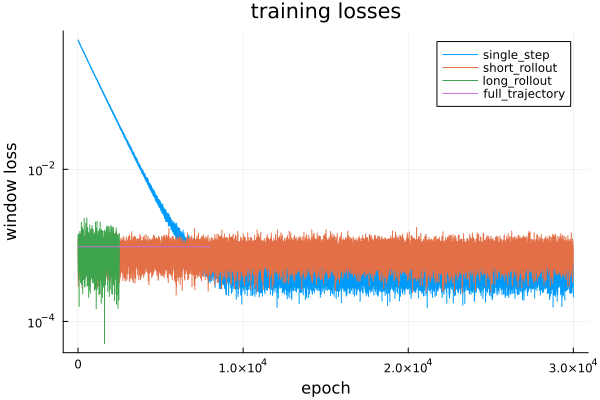

In [79]:
plot(title="training losses", xlabel="epoch", ylabel="window loss", yscale=:log10)
for key in [:single_step, :short_rollout, :long_rollout, :full_trajectory]
    plot!(training_errors[key], label=String(key))
end
plot!()


┌ Info: Saved animation to /var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_JEpglSzCNa.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156


Plots.AnimatedGif("/var/folders/lv/0pc6y84s1s55p74gp083kxlh0000gn/T/jl_JEpglSzCNa.gif")
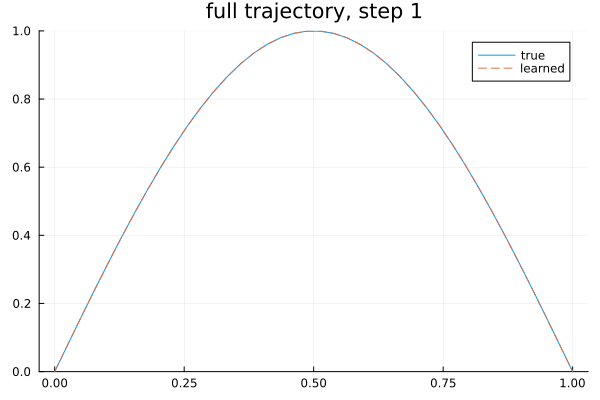

In [80]:
traj = stored_trajectories[:full_trajectory]
@gif for n in 1:2:size(traj.true_traj, 2)
    plot(x_train, traj.true_traj[:,n], label="true", ylim=(0,1), title="full trajectory, step $n")
    plot!(x_train, traj.learned[:,n], label="learned", linestyle=:dash)
end


# Well, that didn't work at all! 

What's going on here? Well, consider the function we're asking the neural network to approximate. We want it to learn $f(x) = \Delta t x_t + x$. But for any $\Delta t$ small enough to stably integrate our true trajectory, this map is very close to $f(x) = x$. So our network is almost certainly stuck learning the identity map.

Check out our `working_neural_PDE.ipynb` for a better idea. 